In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import psycopg2
from sqlalchemy import create_engine
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

conn = psycopg2.connect(
    dbname="bluestock_mf",
    user="postgres",
    password="8128128208",
    host="localhost",
    port="5432"
)

print("Connected to PostgreSQL")

Connected to PostgreSQL


In [5]:
dim_fund = pd.read_sql("SELECT * FROM dim_fund", conn)
dim_date = pd.read_sql("SELECT * FROM dim_date", conn)
fact_nav = pd.read_sql("SELECT * FROM fact_nav", conn)
fact_aum = pd.read_sql("SELECT * FROM fact_aum", conn)
fact_transactions = pd.read_sql("SELECT * FROM fact_transactions", conn)

print(f"dim_fund: {dim_fund.shape}")
print(f"dim_date: {dim_date.shape}")
print(f"fact_nav: {fact_nav.shape}")
print(f"fact_aum: {fact_aum.shape}")
print(f"fact_transactions: {fact_transactions.shape}")

dim_fund: (40, 8)
dim_date: (1150, 9)
fact_nav: (46000, 4)
fact_aum: (70, 4)
fact_transactions: (23547, 8)


In [6]:
# Merge NAV with scheme names and dates
nav_with_names = fact_nav.merge(dim_fund[['scheme_code', 'scheme_name']], on='scheme_code', how='left')
nav_with_names = nav_with_names.merge(dim_date[['date_id', 'full_date']], on='date_id', how='left')

# Convert full_date to datetime
nav_with_names['full_date'] = pd.to_datetime(nav_with_names['full_date'])

# Filter years 2022-2026
nav_filtered = nav_with_names[(nav_with_names['full_date'].dt.year >= 2022) & (nav_with_names['full_date'].dt.year <= 2026)]

# Interactive line chart
import plotly.express as px
import plotly.graph_objects as go

fig = px.line(nav_filtered, x='full_date', y='nav_value', color='scheme_name',
              title='Daily NAV for All 40 Schemes (2022-2026)',
              labels={'nav_value': 'Net Asset Value (₹)', 'full_date': 'Date', 'scheme_name': 'Scheme'})
fig.update_layout(height=600, legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1))

# Add shaded regions for 2023 bull run and 2024 correction
fig.add_vrect(x0='2023-01-01', x1='2023-12-31', fillcolor='green', opacity=0.1, layer='below', line_width=0)
fig.add_annotation(x='2023-07-01', y=nav_filtered['nav_value'].max() * 0.8, text='2023 Bull Run', showarrow=False)
fig.add_vrect(x0='2024-01-01', x1='2024-12-31', fillcolor='red', opacity=0.1, layer='below', line_width=0)
fig.add_annotation(x='2024-07-01', y=nav_filtered['nav_value'].max() * 0.6, text='2024 Correction', showarrow=False)

fig.show()

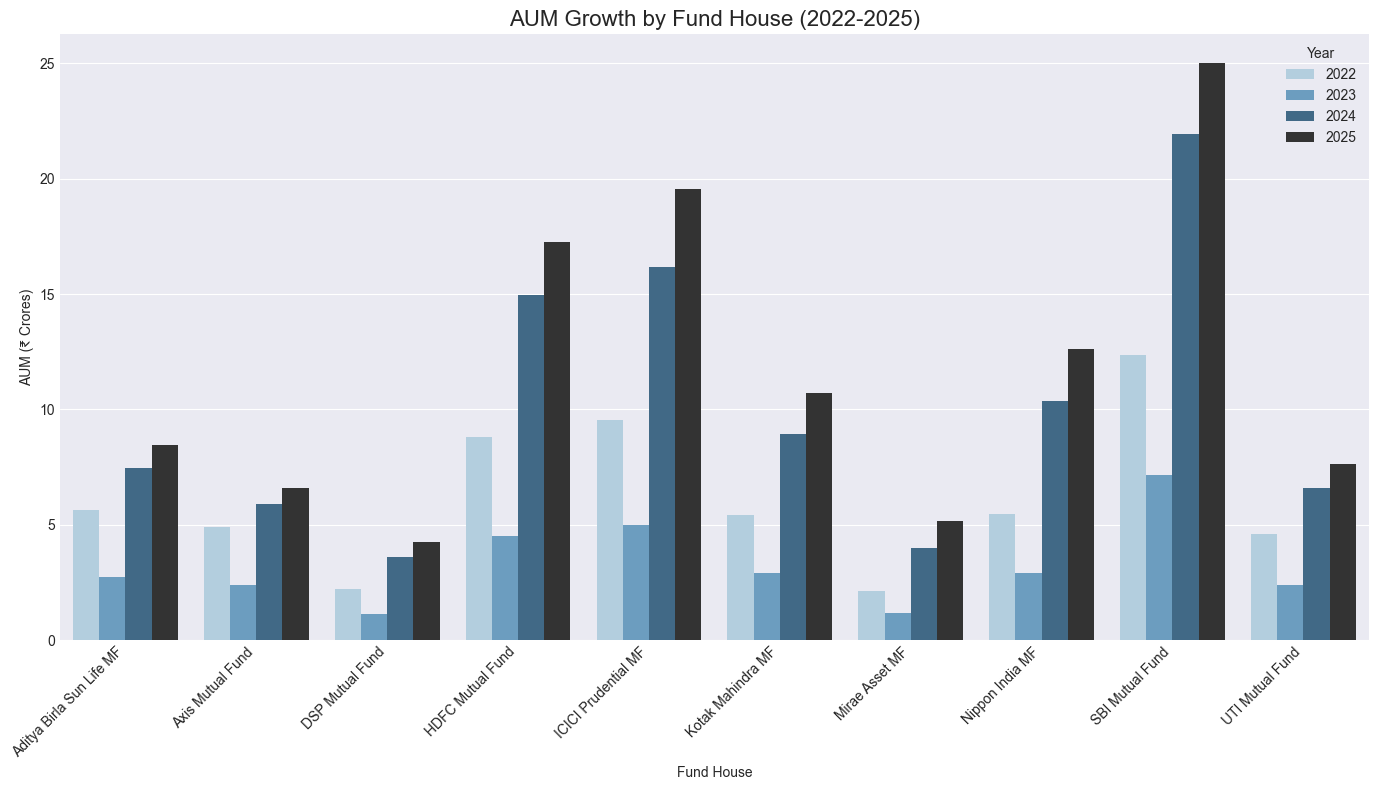

SBI AUM in 2025: 0.0 Lakh Crore


In [7]:
# Merge fact_aum with dim_date to get year
aum_with_year = fact_aum.merge(dim_date[['date_id', 'year']], on='date_id', how='left')

# Filter years 2022-2025
aum_yearly = aum_with_year[aum_with_year['year'].between(2022, 2025)]

# Group by fund_house and year, sum AUM (some fund houses may have multiple entries)
aum_grouped = aum_yearly.groupby(['fund_house', 'year'])['aum_crores'].sum().reset_index()

# Seaborn bar chart
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sns.barplot(data=aum_grouped, x='fund_house', y='aum_crores', hue='year', palette='Blues_d')
plt.title('AUM Growth by Fund House (2022-2025)', fontsize=16)
plt.xlabel('Fund House')
plt.ylabel('AUM (₹ Crores)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

# Highlight SBI dominance
sbi_2025 = aum_grouped[(aum_grouped['fund_house'] == 'SBI Mutual Fund') & (aum_grouped['year'] == 2025)]['aum_crores'].values
if len(sbi_2025) > 0:
    print(f"SBI AUM in 2025: {sbi_2025[0] / 100000:.1f} Lakh Crore")

In [19]:
from pathlib import Path
processed_path = Path("d:/bluestock_mf_capstone/data/processed")

monthly_sip = pd.read_csv(processed_path / "04_monthly_sip_inflows_cleaned.csv")
print("Columns in file:", monthly_sip.columns.tolist())
print("First few rows:")
print(monthly_sip.head())

Columns in file: ['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
First few rows:
   month  sip_inflow_crore  active_sip_accounts_crore  new_sip_accounts_lakh  \
0    NaN             11517                       4.91                   9.10   
1    NaN             11438                       4.93                   8.20   
2    NaN             12328                       5.09                  10.50   
3    NaN             11863                       5.48                   9.52   
4    NaN             12286                       5.55                   8.10   

   sip_aum_lakh_crore  yoy_growth_pct  
0                4.80             NaN  
1                4.85             NaN  
2                5.01             NaN  
3                5.12             NaN  
4                5.15             NaN  


In [21]:
from pathlib import Path
raw_path = Path("d:/bluestock_mf_capstone/data/raw")
processed_path = Path("d:/bluestock_mf_capstone/data/processed")

# Load raw CSV
monthly_sip_raw = pd.read_csv(raw_path / "04_monthly_sip_inflows.csv")

# Convert month to datetime (first day of month)
monthly_sip_raw['month_date'] = pd.to_datetime(monthly_sip_raw['month'], format='%Y-%m')

# Rename columns for clarity (keep original if needed)
monthly_sip_clean = monthly_sip_raw.rename(columns={'sip_inflow_crore': 'sip_inflow_cr'})

# Save to processed
monthly_sip_clean.to_csv(processed_path / "04_monthly_sip_inflows_cleaned.csv", index=False)

print("Cleaned file saved")
print(monthly_sip_clean[['month_date', 'sip_inflow_cr']].head())

Cleaned file saved
  month_date  sip_inflow_cr
0 2022-01-01          11517
1 2022-02-01          11438
2 2022-03-01          12328
3 2022-04-01          11863
4 2022-05-01          12286


In [23]:
# ============================================
# SIP INFLOW TIME-SERIES (Jan 2022 – Dec 2025)
# ============================================

from pathlib import Path
import pandas as pd
import plotly.express as px

# Paths
raw_path = Path("d:/bluestock_mf_capstone/data/raw")
processed_path = Path("d:/bluestock_mf_capstone/data/processed")

# 1. Load raw CSV
raw_sip = pd.read_csv(raw_path / "04_monthly_sip_inflows.csv")

# 2. Convert month column to datetime
raw_sip['month_date'] = pd.to_datetime(raw_sip['month'], format='%Y-%m')

# 3. Rename the inflow column for clarity
raw_sip = raw_sip.rename(columns={'sip_inflow_crore': 'sip_inflow_cr'})

# 4. Save cleaned version (overwrites any bad file)
raw_sip.to_csv(processed_path / "04_monthly_sip_inflows_cleaned.csv", index=False)

# 5. Filter years 2022–2025
sip_filtered = raw_sip[(raw_sip['month_date'].dt.year >= 2022) & (raw_sip['month_date'].dt.year <= 2025)]

# 6. Create Plotly line chart
fig = px.line(
    sip_filtered,
    x='month_date',
    y='sip_inflow_cr',          # ← correct column (values in ₹ crores)
    title='Monthly SIP Inflows (Jan 2022 – Dec 2025)',
    labels={'sip_inflow_cr': 'SIP Inflow (₹ Crores)', 'month_date': 'Month'}
)

# 7. Add annotation for the all-time high (Dec 2025 = ₹31,002 Cr)
fig.add_annotation(
    x='2025-12-01',
    y=31002,
    text="All-time high: ₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    arrowcolor='red'
)

fig.update_layout(height=500)
fig.show()

# Optional: print the data to verify
print(sip_filtered[['month_date', 'sip_inflow_cr']].tail(3))

   month_date  sip_inflow_cr
45 2025-10-01          29529
46 2025-11-01          30200
47 2025-12-01          31002


Recreated cleaned file
  month_date         category  net_inflow_cr
0 2024-04-01        Large Cap         2413.0
1 2024-04-01          Mid Cap         3897.0
2 2024-04-01        Small Cap         3533.0
3 2024-04-01        Flexi Cap         4947.0
4 2024-04-01  Large & Mid Cap         4214.0


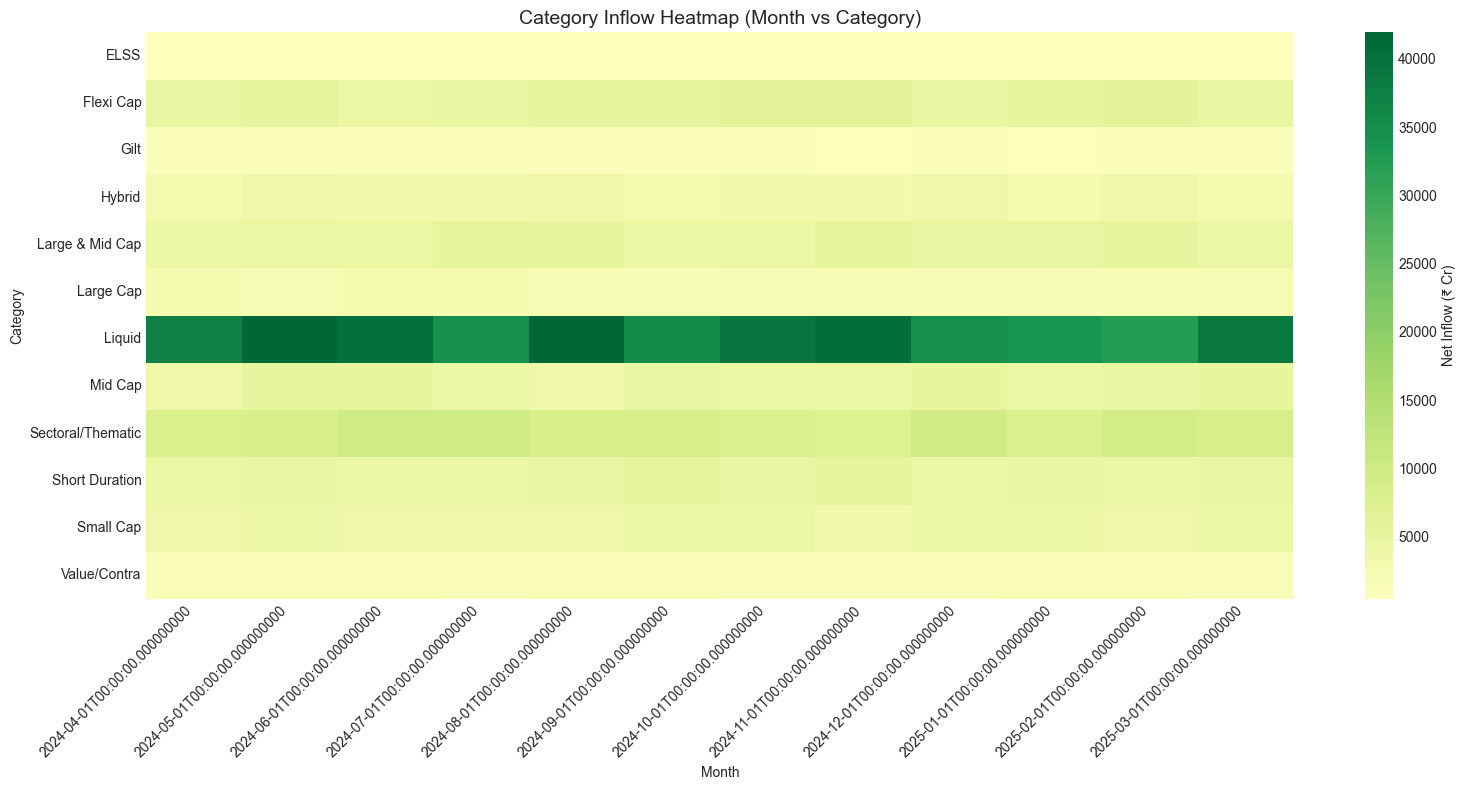

In [28]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

raw_path = Path("d:/bluestock_mf_capstone/data/raw")
processed_path = Path("d:/bluestock_mf_capstone/data/processed")

# 1. Load raw category inflows
cat_raw = pd.read_csv(raw_path / "05_category_inflows.csv")

# 2. Convert month to datetime
cat_raw['month_date'] = pd.to_datetime(cat_raw['month'], format='%Y-%m')

# 3. Keep required columns (adjust names if needed)
# Assuming columns: month, category, net_inflow_crore
cat_clean = cat_raw.rename(columns={'net_inflow_crore': 'net_inflow_cr'})

# 4. Save cleaned
cat_clean.to_csv(processed_path / "05_category_inflows_cleaned.csv", index=False)
print("Recreated cleaned file")
print(cat_clean[['month_date', 'category', 'net_inflow_cr']].head())

# 5. Pivot for heatmap
pivot = cat_clean.pivot(index='category', columns='month_date', values='net_inflow_cr')

# 6. Plot heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(pivot, cmap='RdYlGn', center=0, annot=False, cbar_kws={'label': 'Net Inflow (₹ Cr)'})
plt.title('Category Inflow Heatmap (Month vs Category)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [29]:
# Load raw folio count
folio_raw = pd.read_csv(raw_path / "06_industry_folio_count.csv")

# Check columns
print("Columns:", folio_raw.columns.tolist())
print(folio_raw.head())

# Convert month to datetime (assuming first column is date)
date_col = folio_raw.columns[0]
folio_raw['month_date'] = pd.to_datetime(folio_raw[date_col], format='%Y-%m')

# Identify folio count column (likely 'folio_count_cr')
val_col = [c for c in folio_raw.columns if 'folio' in c.lower()][0]
folio_clean = folio_raw.rename(columns={val_col: 'folio_count_cr'})
folio_clean = folio_clean[['month_date', 'folio_count_cr']]

# Save cleaned
folio_clean.to_csv(processed_path / "06_industry_folio_count_cleaned.csv", index=False)

# Filter 2022–2025
folio_filtered = folio_clean[(folio_clean['month_date'].dt.year >= 2022) & (folio_clean['month_date'].dt.year <= 2025)]

import plotly.express as px
fig = px.line(folio_filtered, x='month_date', y='folio_count_cr',
              title='Industry Folio Count Growth (Jan 2022 – Dec 2025)',
              labels={'folio_count_cr': 'Folio Count (Crores)', 'month_date': 'Month'})
fig.add_annotation(x='2022-01-15', y=13.26, text="Start: 13.26 Cr", showarrow=True)
fig.add_annotation(x='2025-12-15', y=26.12, text="End: 26.12 Cr", showarrow=True)
fig.update_layout(height=500)
fig.show()

Columns: ['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


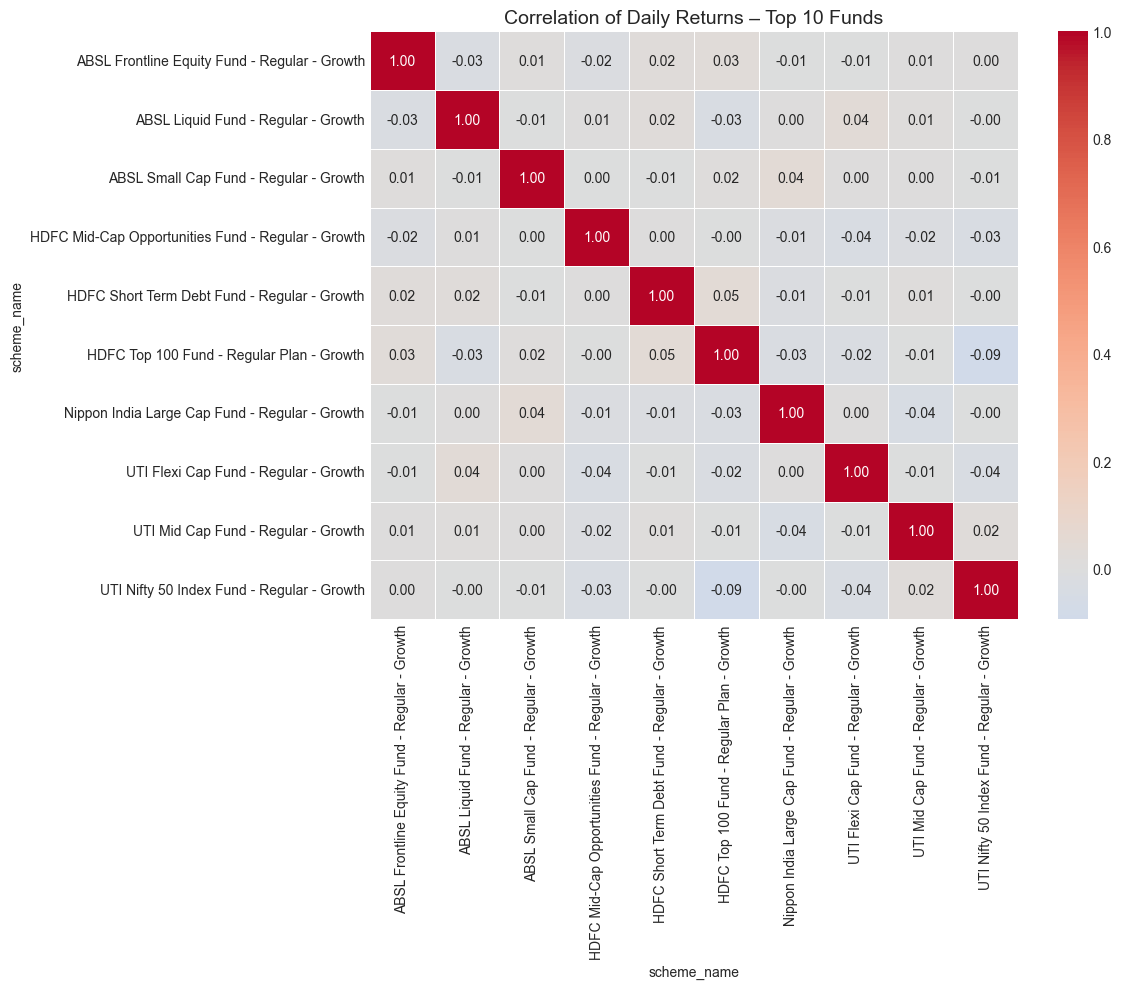

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


# Load necessary data (already in memory, but ensure)
# fact_nav, dim_fund, dim_date should exist from previous cells

# Merge to get scheme names and dates
nav_returns = fact_nav.merge(dim_fund[['scheme_code', 'scheme_name']], on='scheme_code')
nav_returns = nav_returns.merge(dim_date[['date_id', 'full_date']], on='date_id')
nav_returns['full_date'] = pd.to_datetime(nav_returns['full_date'])

# Select 10 funds (choose top 10 by AUM or random for demo)
# For demonstration, pick the first 10 unique scheme codes
top_schemes = nav_returns['scheme_name'].unique()[:10]
nav_subset = nav_returns[nav_returns['scheme_name'].isin(top_schemes)]

# Pivot: rows = date, columns = scheme_name, values = nav_value
nav_pivot = nav_subset.pivot(index='full_date', columns='scheme_name', values='nav_value')
# Calculate daily returns
returns = nav_pivot.pct_change().dropna()

# Correlation matrix
corr = returns.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation of Daily Returns – Top 10 Funds', fontsize=14)
plt.tight_layout()
plt.show()

In [35]:
# Load the cleaned portfolio
portfolio = pd.read_csv(processed_path / "09_portfolio_holdings_cleaned.csv")

# Identify sector and weight columns (auto-detect)
sector_col = [col for col in portfolio.columns if 'sector' in col.lower()][0]
weight_col = [col for col in portfolio.columns if 'weight' in col.lower() or 'allocation' in col.lower() or 'pct' in col.lower()][0]

# Aggregate weights by sector
sector_weights = portfolio.groupby(sector_col)[weight_col].sum().reset_index()
sector_weights = sector_weights.sort_values(weight_col, ascending=False).head(10)  # top 10 sectors

# Donut chart
import plotly.express as px
fig = px.pie(sector_weights, values=weight_col, names=sector_col,
             title='Top 10 Sector Allocation (Aggregated Across All Equity Funds)',
             hole=0.4, color_discrete_sequence=px.colors.qualitative.Set3)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(height=500)
fig.show()

In [36]:
# Merge NAV data with category information
nav_with_cat = nav_returns.merge(dim_fund[['scheme_code', 'category']], on='scheme_code')

# Group by date and category to get average NAV
cat_avg_nav = nav_with_cat.groupby(['full_date', 'category'])['nav_value'].mean().reset_index()

# Plotly line chart
fig = px.line(cat_avg_nav, x='full_date', y='nav_value', color='category',
              title='Average NAV by Category (2022-2026)',
              labels={'nav_value': 'Average NAV (₹)', 'full_date': 'Date'})
fig.update_layout(height=500)
fig.show()